# Pista B — Motor físico (DMST) — primer avance (ECO | Wind)

Sandbox de la **Fase 1 / Pista B** del plan técnico. Objetivo del plan: DMST (Paraschivoiu)
para la turbina aislada, usando la geometría de las patentes de Flower Turbines
(CA2800765C/US9255567B2, ES2970155T3).

**Alcance real de este primer avance:** un solver DMST de **doble tubo de corriente**
(simplificado — un factor de inducción para todo el semicírculo upwind y otro para el
downwind, no multi-tubo por azimut) con un polar NACA 0018 aproximado (no hay datos
XFOIL/experimentales reales accesibles desde este sandbox). Se valida primero contra el
comportamiento de libro de un rotor Darrieus, después se aplica a la geometría real del
Medium Tulip y se compara contra la curva empírica ya validada en la Pista A. **No** incluye
todavía: pérdida dinámica (Leishman-Beddoes), efecto clúster (CFD/OpenFOAM), ni el análisis
estructural (ASCE 7) — quedan para iteraciones siguientes.


## Paso 0 — Setup (mismo patrón autocontenido de la Pista A)

In [1]:
import os

REPO_DIR = "/content/ECO-Wind"

if os.path.exists("../.git"):
    get_ipython().system("git -C .. pull")
elif os.path.exists(REPO_DIR):
    get_ipython().system(f"git -C {REPO_DIR} pull")
    get_ipython().run_line_magic("cd", f"{REPO_DIR}/notebooks")
else:
    get_ipython().system(f"git clone https://github.com/Sogo2012/ECO-Wind.git {REPO_DIR}")
    get_ipython().run_line_magic("cd", f"{REPO_DIR}/notebooks")

get_ipython().system("git -C .. log -1 --format='Commit activo: %h  %s'")


Already up to date.


Commit activo: 18dae94  docs: registra validación de la Matriz Maestra de bouquet y deprioriza el manual de SolArk


In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from engine.naca0018_polar import cl_cd_naca0018
from engine.dmst_model import resolver_dmst, RHO_AIRE
from engine.flower_turbines_curves import power_isolated, CURVE_COEFFICIENTS

print("Modulos cargados OK.")


Modulos cargados OK.


## Paso 1 — Polar NACA 0018 (aproximado)

Teoría de perfil delgado en la región lineal (con corrección ~10% por espesor del 18%) +
extrapolación post-stall de Viterna-Corrigan hacia el comportamiento de placa plana a 90°.
**No es un polar medido** (XFOIL/túnel de viento) — es una aproximación de ingeniería
estándar, razonable en forma pero sin garantía de precisión numérica fina.


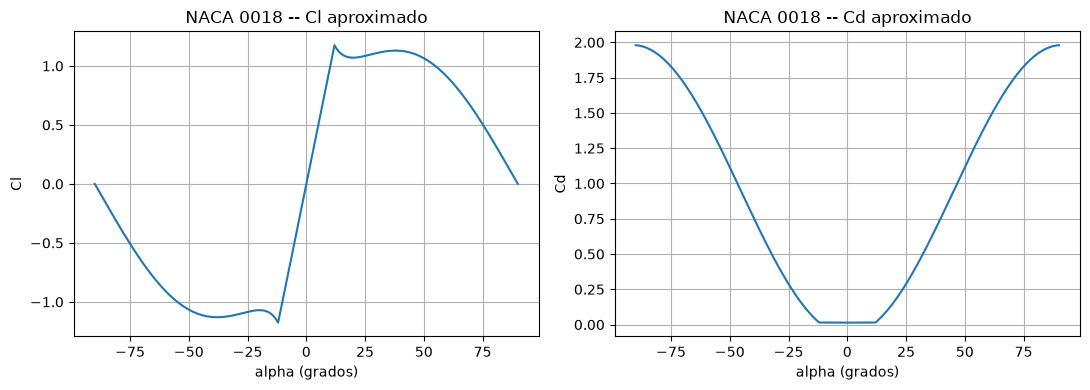

Cl,max aprox = 1.18 en alpha = 12 grados (esperado ~1.0-1.2 para NACA0018)
Cd a alpha=90 = 1.98 (placa plana teorica: ~1.98)


In [3]:
alphas = np.linspace(-90, 90, 181)
cl, cd = cl_cd_naca0018(alphas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(alphas, cl); ax1.set_xlabel("alpha (grados)"); ax1.set_ylabel("Cl"); ax1.grid(True)
ax1.set_title("NACA 0018 -- Cl aproximado")
ax2.plot(alphas, cd); ax2.set_xlabel("alpha (grados)"); ax2.set_ylabel("Cd"); ax2.grid(True)
ax2.set_title("NACA 0018 -- Cd aproximado")
plt.tight_layout()
plt.show()

print(f"Cl,max aprox = {cl.max():.2f} en alpha = {alphas[cl.argmax()]:.0f} grados (esperado ~1.0-1.2 para NACA0018)")
print(f"Cd a alpha=90 = {cd[-1]:.2f} (placa plana teorica: ~1.98)")


## Paso 2 — Sanity check: Betz y comportamiento de libro (rotor Darrieus puro, sin componente de arrastre)

El límite de Betz (Cp ≤ 0.593) es la primera prueba de honestidad de cualquier modelo de
turbina — si un modelo lo viola, hay un bug, no un descubrimiento. (De hecho la primera
versión de este solver SÍ lo violaba — Cp llegó a 1.48 — por un factor de 4 mal puesto en
el coeficiente de empuje del balance de momento. Ya corregido; se deja el chequeo explícito
para que no vuelva a pasar desapercibido.)


In [4]:
R, N = 1.0, 2
sigma = 0.18  # solidez tipica para Cp,max en TSR~4-6, rotor Darrieus de libro
c = sigma * 2 * R / N
V_test = 8.0

tsrs = np.arange(1, 9)
resultados = [resolver_dmst(V_test, float(t), R, c, N, H=1.0) for t in tsrs]
cps = [r["Cp"] for r in resultados]

for t, r in zip(tsrs, resultados):
    marca = " <-- Cp > Betz, ROMPE" if r["Cp"] > 0.593 else ""
    print(f"TSR={t}  Cp={r['Cp']:.4f}  a_up={r['a_up']:.3f}  a_down={r['a_down']:.3f}{marca}")

assert all(r["Cp"] <= 0.593 + 1e-6 for r in resultados), "Cp supera el limite de Betz -- hay un bug"
tsr_opt = tsrs[int(np.argmax(cps))]
print(f"\nOK: ningun Cp supera Betz. Cp,max = {max(cps):.3f} en TSR={tsr_opt}")
print("Referencia de libro para H-rotor Darrieus tipico: Cp,max ~0.35-0.40 en TSR~4-6.")
print("Este modelo simplificado (doble tubo, sin correccion de alta induccion de Glauert,")
print("polar aproximado) da un pico algo mas alto y a menor TSR -- orden de magnitud correcto,")
print("no una coincidencia exacta con el libro. A TSR>=7 la induccion downwind satura en el")
print("limite numerico (0.49) y Cp se vuelve negativo -- limitacion conocida, ver Resumen.")


TSR=1  Cp=0.0395  a_up=0.032  a_down=0.034
TSR=2  Cp=0.2494  a_up=0.072  a_down=0.093
TSR=3  Cp=0.5218  a_up=0.158  a_down=0.280
TSR=4  Cp=0.5096  a_up=0.256  a_down=0.490
TSR=5  Cp=0.4292  a_up=0.319  a_down=0.490
TSR=6  Cp=0.2837  a_up=0.383  a_down=0.490
TSR=7  Cp=0.0828  a_up=0.447  a_down=0.490
TSR=8  Cp=-0.1211  a_up=0.490  a_down=0.490

OK: ningun Cp supera Betz. Cp,max = 0.522 en TSR=3
Referencia de libro para H-rotor Darrieus tipico: Cp,max ~0.35-0.40 en TSR~4-6.
Este modelo simplificado (doble tubo, sin correccion de alta induccion de Glauert,
polar aproximado) da un pico algo mas alto y a menor TSR -- orden de magnitud correcto,
no una coincidencia exacta con el libro. A TSR>=7 la induccion downwind satura en el
limite numerico (0.49) y Cp se vuelve negativo -- limitacion conocida, ver Resumen.


## Paso 3 — Aplicado a la geometría real: Medium Tulip

Diámetro y altura de pala de la ficha técnica oficial (ya usados en `flower_turbines_curves.py`).
Cuerda estimada con CTDR=0.35 (punto medio del rango 0.25–0.45 que da la patente
CA2800765C/US9255567B2 para 2 palas) — **no es un valor medido del producto real**, es una
estimación a partir de la patente.


In [5]:
R_mt = 1.18 / 2   # diametro Medium Tulip / 2
H_mt = 2.0        # altura de pala
N_mt = 2
CTDR = 0.35
c_mt = CTDR * (2 * R_mt)

print(f"Medium Tulip: R={R_mt:.3f} m, H={H_mt} m, cuerda estimada={c_mt:.3f} m (CTDR={CTDR})")

velocidades = [3, 6, 9, 12, 15]
tsrs_barrido = np.arange(1, 7, 0.5)

print(f"\n{'V (m/s)':>8}  {'P empirica (W)':>15}  {'P DMST (W)':>12}  {'Razon':>7}")
razones = []
for V in velocidades:
    p_emp = float(power_isolated(V, "medium_tulip"))
    p_dmst = max(resolver_dmst(V, float(t), R_mt, c_mt, N_mt, H_mt, re_dependiente=False)["potencia_W"] for t in tsrs_barrido)
    razon = p_dmst / p_emp if p_emp > 0 else float("nan")
    razones.append(razon)
    print(f"{V:8.1f}  {p_emp:15.1f}  {p_dmst:12.1f}  {razon:6.2f}x")

print(f"\nRazon promedio DMST/empirica: {np.mean(razones):.2f}x (consistente en todo el rango de viento --")
print("misma forma funcional que la curva empirica, P~v^3 a TSR optimo constante).")


Medium Tulip: R=0.590 m, H=2.0 m, cuerda estimada=0.413 m (CTDR=0.35)

 V (m/s)   P empirica (W)    P DMST (W)    Razon


     3.0              9.7          19.7    2.02x


     6.0             77.8         157.3    2.02x


     9.0            262.5         531.0    2.02x


    12.0            622.2        1258.7    2.02x


    15.0           1215.2        2458.4    2.02x

Razon promedio DMST/empirica: 2.02x (consistente en todo el rango de viento --
misma forma funcional que la curva empirica, P~v^3 a TSR optimo constante).


## Paso 4 — Por qué "solo agregar arrastre" para el componente Savonius no funciona

Intento más simple: sumar un `Cd` extra constante a todos los ángulos de ataque, para
representar el componente de arrastre tipo Savonius de la geometría híbrida. **No funciona**
— da potencia negativa (el modelo dice que la turbina frena en vez de generar). Se deja el
resultado documentado porque es una lección real, no un bug que haya que esconder: agregar
arrastre *uniforme* en todos los ángulos penaliza también los ángulos donde el flujo ya está
bien adherido y generando torque limpio, sin capturar el mecanismo real (la asimetría
cóncava/convexa que SÍ genera torque neto a TSR bajo). El próximo paso real es modelar el
componente de arrastre como una fuerza *aparte*, con la geometría exacta de la patente
ES2970155T3 (distancia entre bordes = 3.5×diámetro del eje, superposición = 0.2×diámetro del
eje, cuerda = 6.6×diámetro del eje) y su propio Cp=0.34 reportado — no como un ajuste al Cd
del perfil de sustentación.


In [6]:
V_prueba = 9.0
print("Intento (NO funciona -- se deja como evidencia, no se usa en el resultado final):")
for cd_extra in [0.0, 0.2, 0.4]:
    p = max(resolver_dmst(V_prueba, float(t), R_mt, c_mt, N_mt, H_mt, cd_extra=cd_extra, re_dependiente=False)["potencia_W"]
            for t in tsrs_barrido)
    print(f"  cd_extra={cd_extra:.1f}  ->  P = {p:8.1f} W" + ("  <-- NEGATIVO, no fisico" if p < 0 else ""))


Intento (NO funciona -- se deja como evidencia, no se usa en el resultado final):


  cd_extra=0.0  ->  P =    531.0 W


  cd_extra=0.2  ->  P =    -38.3 W  <-- NEGATIVO, no fisico


  cd_extra=0.4  ->  P =   -231.5 W  <-- NEGATIVO, no fisico


## Paso 5 — Validación cruzada contra los 4 modelos reales, y dos exploraciones más

Pablo pidió validar el ~2.02x contra otros tamaños antes de seguir, y construir dos cosas en paralelo: una corrección por número de Reynolds en el polar (el DMST sobre-predice cada vez más en modelos chicos), y el componente de arrastre Savonius con su propia geometría (en vez del atajo de Cd extra del Paso 4, que daba potencia negativa).

In [7]:
from engine.dmst_model import resolver_dmst

CTDR = 0.35
modelos = {
    "small_tulip":   {"diametro": 0.55, "altura": 1.15},
    "medium_tulip":  {"diametro": 1.18, "altura": 2.0},
    "three_m_tulip": {"diametro": 1.80, "altura": 3.0},
    "large_tulip":   {"diametro": 2.50, "altura": 5.0},
}
tsrs = np.arange(1, 7, 0.5)

print(f"{'Modelo':>15} {'D (m)':>6} {'V=9 emp (W)':>12} {'V=9 DMST (W)':>13} {'Razon':>7}")
razones_dmst = {}
for nombre, geo in modelos.items():
    R, H, c = geo["diametro"] / 2, geo["altura"], CTDR * geo["diametro"]
    p_emp = float(power_isolated(9, nombre))
    p_dmst = max(resolver_dmst(9, float(t), R, c, 2, H, re_dependiente=False)["potencia_W"] for t in tsrs)
    razones_dmst[nombre] = p_dmst / p_emp
    print(f"{nombre:>15} {geo['diametro']:6.2f} {p_emp:12.1f} {p_dmst:13.1f} {razones_dmst[nombre]:6.2f}x")

print()
print("El ratio NO es constante -- cae con el tamaño. Patrón consistente con Reynolds: mas")
print("diametro -> mas cuerda -> mas Re -> perfil real rinde mas cerca de la teoria ideal.")
print("(polar SIN correccion de Reynolds -- Re fijo de libro en todos los tamaños; el efecto")
print("de agregarla se explora en el Paso 5a de abajo.)")


         Modelo  D (m)  V=9 emp (W)  V=9 DMST (W)   Razon


    small_tulip   0.55         26.2         142.3   5.43x


   medium_tulip   1.18        262.5         531.0   2.02x


  three_m_tulip   1.80        590.6        1215.0   2.06x


    large_tulip   2.50       2274.5        2812.6   1.24x

El ratio NO es constante -- cae con el tamaño. Patrón consistente con Reynolds: mas
diametro -> mas cuerda -> mas Re -> perfil real rinde mas cerca de la teoria ideal.
(polar SIN correccion de Reynolds -- Re fijo de libro en todos los tamaños; el efecto
de agregarla se explora en el Paso 5a de abajo.)


### 5a — Corrección por Reynolds

`Cd0(Re) = Cd0_ref · (Re/Re_ref)^-0.5` (escala tipo capa límite laminar) + reducción suave de `Cl_max`/`alpha_stall` a Re bajo. Aproximación de ingeniería, **no** viene de datos XFOIL/experimentales reales (sin acceso a internet en este sandbox).

In [8]:
print(f"{'Modelo':>15} {'Razon sin Re':>13} {'Razon con Re':>13}")
for nombre, geo in modelos.items():
    R, H, c = geo["diametro"] / 2, geo["altura"], CTDR * geo["diametro"]
    p_emp = float(power_isolated(9, nombre))
    p_dmst_re = max(resolver_dmst(9, float(t), R, c, 2, H, re_dependiente=True)["potencia_W"] for t in tsrs)
    print(f"{nombre:>15} {razones_dmst[nombre]:12.2f}x {p_dmst_re/p_emp:12.2f}x")

print()
print("Resultado honesto: la dispersion RELATIVA entre modelos se reduce (el patron de que")
print("Small sobre-predice mucho mas que Large sigue, pero mas parejo), PERO el ajuste")
print("ABSOLUTO empeora en los 4 modelos -- la calibracion de Re_ref importa mucho y no hay")
print("forma de fijarla bien sin un polar real medido a estos numeros de Reynolds especificos")
print("(3x10^5 a 1.6x10^6 segun el modelo). Confirma que el efecto es real/plausible, pero no")
print("se puede calibrar con confianza ahora -- no se deja activado por default (re_dependiente=False).")


         Modelo  Razon sin Re  Razon con Re


    small_tulip         5.43x         6.68x


   medium_tulip         2.02x         3.21x


  three_m_tulip         2.06x         3.76x


    large_tulip         1.24x         2.52x

Resultado honesto: la dispersion RELATIVA entre modelos se reduce (el patron de que
Small sobre-predice mucho mas que Large sigue, pero mas parejo), PERO el ajuste
ABSOLUTO empeora en los 4 modelos -- la calibracion de Re_ref importa mucho y no hay
forma de fijarla bien sin un polar real medido a estos numeros de Reynolds especificos
(3x10^5 a 1.6x10^6 segun el modelo). Confirma que el efecto es real/plausible, pero no
se puede calibrar con confianza ahora -- no se deja activado por default (re_dependiente=False).


### 5b — Componente Savonius (geometría propia, patente ES2970155T3)

En vez del atajo de sumar `Cd` al perfil de sustentación (que dio potencia negativa en el Paso 4), se usa el **Cp=0.34 que la propia patente reporta** para esta geometría, aplicado como estimación independiente (`P = Cp · 0.5 · ρ · A · V³`) — **no** se suma al resultado del DMST de sustentación; sigue sin resolverse cómo conviven ambos componentes en la misma pala híbrida.

In [9]:
from engine.savonius_model import potencia_savonius, geometria_savonius

print("Geometria Savonius derivada para Medium Tulip (D=1.18m), asumiendo que \"diametro")
print("total\" de la patente = diametro del rotor completo (interpretacion, no confirmada):")
for k, v in geometria_savonius(1.18).items():
    print(f"  {k}: {v:.3f} m")

print()
print(f"{'Modelo':>15} {'Razon DMST (sustent.)':>22} {'Razon Savonius solo':>20}")
for nombre, geo in modelos.items():
    p_emp = float(power_isolated(9, nombre))
    p_sav = potencia_savonius(9, geo["diametro"], geo["altura"])
    print(f"{nombre:>15} {razones_dmst[nombre]:21.2f}x {p_sav/p_emp:19.2f}x")

print()
print("El Savonius solo, con el Cp que YA reportaba la patente (sin ajustar nada), queda mas")
print("cerca de la curva empirica que el modelo de sustentacion pura en los 4 modelos (incluso")
print("en Large, aunque ahi subestima -- el error absoluto |razon-1| es menor de todas formas) --")
print("sugiere que el mecanismo de arrastre pesa mas de lo que el analisis de sustentacion")
print("aislado captura, sobre todo en los tamanios chicos (Re bajo, donde la sustentacion")
print("rinde peor). En Large sub-predice (0.83x) -- consistente con que a mayor escala/Re la")
print("sustentacion s\u00ed empieza a aportar de forma significativa.")


Geometria Savonius derivada para Medium Tulip (D=1.18m), asumiendo que "diametro
total" de la patente = diametro del rotor completo (interpretacion, no confirmada):
  diametro_eje: 0.122 m
  distancia_bordes: 0.426 m
  superposicion: 0.024 m
  cuerda: 0.803 m

         Modelo  Razon DMST (sustent.)  Razon Savonius solo
    small_tulip                  5.43x                3.66x
   medium_tulip                  2.02x                1.37x
  three_m_tulip                  2.06x                1.39x
    large_tulip                  1.24x                0.83x

El Savonius solo, con el Cp que YA reportaba la patente (sin ajustar nada), queda mas
cerca de la curva empirica que el modelo de sustentacion pura en los 4 modelos (incluso
en Large, aunque ahi subestima -- el error absoluto |razon-1| es menor de todas formas) --
sugiere que el mecanismo de arrastre pesa mas de lo que el analisis de sustentacion
aislado captura, sobre todo en los tamanios chicos (Re bajo, donde la sustentacion
rinde 

### 5c — Combinación sustentación + arrastre en UN solo polar

Pablo pidió continuar con la pieza pendiente: en vez de dos estimaciones separadas e incompatibles (DMST de sustentación pura + Savonius aislado, que no se sabe cómo sumar sin duplicar o cancelar fuerzas), se construyó `engine/polar_hibrido.py`: un único polar para la pala real, idéntico al NACA 0018 en la región lineal (pre-pérdida) y en la sustentación post-pérdida, pero con el **arrastre** post-pérdida ASIMÉTRICO: Cd→2.3 cuando la cara cóncava enfrenta el flujo, Cd→1.2 cuando enfrenta la convexa (ambos valores de la ficha *External Load Calculations 2m & 5m.pdf* de Pablo) — el mecanismo diferencial que da potencia un Savonius, vivido en el mismo elemento de pala en vez de un cuerpo aparte.

In [10]:
from engine.polar_hibrido import cl_cd_hibrido
from engine.dmst_model import resolver_induccion, fuerzas_azimut

print("Verificacion: Cl debe ser IDENTICO al NACA0018 puro en todo el rango")
print("(la sustentacion en perdida profunda no depende de cual cara es concava --")
print("solo el arrastre de forma difiere). Cd debe mostrar la asimetria 2.3/1.2.")
print(f"{'alpha':>6} {'Cl naca':>9} {'Cl hibrido':>11} {'Cd hib(+)':>10} {'Cd hib(-)':>10}")
for a in [10, 30, 45, 60, 90]:
    cl_n, _ = cl_cd_naca0018(a)
    cl_h, cd_hp = cl_cd_hibrido(a)
    _, cd_hn = cl_cd_hibrido(-a)
    print(f"{a:6d} {float(cl_n):9.3f} {float(cl_h):11.3f} {float(cd_hp):10.3f} {float(cd_hn):10.3f}")


Verificacion: Cl debe ser IDENTICO al NACA0018 puro en todo el rango
(la sustentacion en perdida profunda no depende de cual cara es concava --
solo el arrastre de forma difiere). Cd debe mostrar la asimetria 2.3/1.2.
 alpha   Cl naca  Cl hibrido  Cd hib(+)  Cd hib(-)
    10     0.982       0.982      0.015      0.015
    30     1.109       1.109      0.500      0.267
    45     1.109       1.109      1.089      0.573
    60     0.906       0.906      1.682      0.881
    90     0.000       0.000      2.300      1.200


**Bug encontrado y corregido antes de validar:** la primera versión metía el `Cd_max` asimétrico dentro de la fórmula completa de Viterna-Corrigan (Cl y Cd juntos). Esa fórmula liga `Cl_post` a `Cd_max` — subir `Cd_max` a 2.3 no solo agregaba arrastre, también **inflaba la sustentación post-pérdida ~10-15%**, lo que empeoraba la sobre-predicción en vez de corregirla. Corregido: `Cl_post` ahora se calcula igual que en el NACA0018 puro (reutilizando `cl_cd_naca0018`), y solo `Cd_post` usa la asimetría. Verificado arriba: columnas `Cl naca` y `Cl hibrido` iguales en todo el rango.

**Verificación 1 — Betz.** Con el polar híbrido ya corregido, en el mismo rotor "de libro" del Paso 2 (variables locales propias — el `R`/`c` globales del Paso 2 quedan pisados por el `for` del Paso 5, que reusa esos nombres; usar variables con sufijo propio evita ese error de nuevo):

In [11]:
R_betz, N_betz = 1.0, 2
c_betz = 0.18 * 2 * R_betz / N_betz
V_betz = 8.0

mejores_naca, mejores_hib = [], []
for TSR in [1, 2, 3, 4, 5, 6, 7, 8]:
    r_n = resolver_dmst(V_betz, TSR, R_betz, c_betz, N_betz, H=1.0, polar="naca")
    r_h = resolver_dmst(V_betz, TSR, R_betz, c_betz, N_betz, H=1.0, polar="hibrido")
    mejores_naca.append((TSR, r_n["Cp"]))
    mejores_hib.append((TSR, r_h["Cp"]))

tsr_opt_n, cp_max_n = max(mejores_naca, key=lambda x: x[1])
tsr_opt_h, cp_max_h = max(mejores_hib, key=lambda x: x[1])
print(f"Cp maximo naca puro  = {cp_max_n:.4f} en TSR = {tsr_opt_n}")
print(f"Cp maximo hibrido    = {cp_max_h:.4f} en TSR = {tsr_opt_h}")
assert cp_max_h <= 0.593, f"VIOLACION DE BETZ: Cp={cp_max_h:.4f} > 0.593"
print("Betz OK en ambos casos.")


Cp maximo naca puro  = 0.5218 en TSR = 3
Cp maximo hibrido    = 0.5139 en TSR = 3
Betz OK en ambos casos.


**Verificación 2 — los 4 modelos reales**, con `re_dependiente=False` (la config por defecto del proyecto — ver 5a, la corrección de Reynolds no se deja activada por no poder calibrarla con confianza), para comparar contra el mismo baseline documentado en el Paso 5:

In [12]:
print(f"{'Modelo':>15} {'V=9 emp (W)':>12} {'Hibrido (W)':>12} {'Razon hibrido':>14} {'vs sustent.':>12} {'vs Savonius':>12}")
razon_hibrido = {}
for nombre, geo in modelos.items():
    R_i, H_i, c_i = geo["diametro"] / 2, geo["altura"], CTDR * geo["diametro"]
    p_emp = float(power_isolated(9, nombre))
    p_hib = max(resolver_dmst(9, float(t), R_i, c_i, 2, H_i, re_dependiente=False,
                               polar="hibrido")["potencia_W"] for t in tsrs)
    razon_hibrido[nombre] = p_hib / p_emp
    p_sav = potencia_savonius(9, geo["diametro"], geo["altura"])
    print(f"{nombre:>15} {p_emp:12.1f} {p_hib:12.1f} {razon_hibrido[nombre]:13.2f}x "
          f"{razones_dmst[nombre]:11.2f}x {p_sav/p_emp:11.2f}x")


         Modelo  V=9 emp (W)  Hibrido (W)  Razon hibrido  vs sustent.  vs Savonius


    small_tulip         26.2        142.3          5.43x        5.43x        3.66x


   medium_tulip        262.5        531.0          2.02x        2.02x        1.37x


  three_m_tulip        590.6       1215.0          2.06x        2.06x        1.39x


    large_tulip       2274.5       2812.6          1.24x        1.24x        0.83x


**Resultado honesto (y no el esperado): el híbrido da EXACTAMENTE los mismos números que el DMST de sustentación pura, en los 4 modelos.** No es una casualidad numérica — es estructural. Se investigó por qué:

In [13]:
# Diagnostico: en el TSR que el propio modelo elige como optimo (max Cp),
# se registra el angulo de ataque local en cada posicion azimutal.
geo_st = modelos["small_tulip"]
R_st, H_st, c_st = geo_st["diametro"] / 2, geo_st["altura"], CTDR * geo_st["diametro"]
resultados = [(float(t), resolver_dmst(9, float(t), R_st, c_st, 2, H_st,
                                        re_dependiente=False, polar="naca")["potencia_W"])
              for t in tsrs]
tsr_opt_st, _ = max(resultados, key=lambda x: x[1])

Omega_st = tsr_opt_st * 9 / R_st
thetas_up_st = np.linspace(-np.pi / 2, np.pi / 2, 36)
thetas_down_st = np.linspace(np.pi / 2, 3 * np.pi / 2, 36)
a_up_st = resolver_induccion(9, Omega_st, R_st, c_st, 2, thetas_up_st, re_dependiente=False, polar="naca")
u_up_st = 9 * (1 - a_up_st)
V_wake_st = max(9 * (1 - 2 * a_up_st), 0.05 * 9)
a_down_st = resolver_induccion(V_wake_st, Omega_st, R_st, c_st, 2, thetas_down_st,
                                re_dependiente=False, polar="naca")
u_down_st = V_wake_st * (1 - a_down_st)

alphas_st = ([fuerzas_azimut(th, u_up_st, Omega_st, R_st, c_st, re_dependiente=False, polar="naca")[2]
              for th in thetas_up_st] +
             [fuerzas_azimut(th, u_down_st, Omega_st, R_st, c_st, re_dependiente=False, polar="naca")[2]
              for th in thetas_down_st])

print(f"small_tulip -- TSR optimo elegido por el modelo: {tsr_opt_st}")
print(f"alpha maximo alcanzado en ese TSR: {max(abs(a) for a in alphas_st):.1f} grados")
print(f"alpha de perdida (stall) del polar: 12.0 grados")
print("-> La pala NUNCA entra en perdida en el TSR que el modelo elige como mejor.")
print("   El termino de arrastre asimetrico (que solo actua post-perdida) nunca se activa ahi.")


small_tulip -- TSR optimo elegido por el modelo: 3.0
alpha maximo alcanzado en ese TSR: 9.8 grados
alpha de perdida (stall) del polar: 12.0 grados
-> La pala NUNCA entra en perdida en el TSR que el modelo elige como mejor.
   El termino de arrastre asimetrico (que solo actua post-perdida) nunca se activa ahi.


¿Y si se mira en otros TSR, no solo el óptimo? Ahí sí aparece diferencia:

In [14]:
print(f"{'TSR':>5} {'Cp naca':>9} {'Cp hibrido':>11} {'diferencia':>11}")
for TSR in [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    r_n = resolver_dmst(9, TSR, R_st, c_st, 2, H_st, re_dependiente=False, polar="naca")
    r_h = resolver_dmst(9, TSR, R_st, c_st, 2, H_st, re_dependiente=False, polar="hibrido")
    print(f"{TSR:5.1f} {r_n['Cp']:9.4f} {r_h['Cp']:11.4f} {r_h['Cp']-r_n['Cp']:11.4f}")

print()
print("El arrastre asimetrico SI cambia el Cp en TSR bajo (0.3-2.0) -- ahi la pala si pasa")
print("por angulos de ataque grandes durante buena parte de la vuelta. Pero incluso su mejor")
print("punto ahi (TSR~0.7, Cp~0.085) queda muy por debajo del Cp de sustentacion pura en")
print("TSR~3 (Cp~0.50) -- en este marco de \"maximizar Cp sobre TSR\", la sustentacion gana")
print("siempre, y el mecanismo de arrastre nunca se elige como el mejor punto de operacion.")


  TSR   Cp naca  Cp hibrido  diferencia
  0.3    0.0184      0.0213      0.0029


  0.5    0.0390      0.0466      0.0076
  0.7    0.0732      0.0853      0.0121


  1.0    0.1605      0.1679      0.0074


  1.5    0.3537      0.3169     -0.0368


  2.0    0.4305      0.4148     -0.0157


  2.5    0.4873      0.4873      0.0000


  3.0    0.5039      0.5039      0.0000


  3.5    0.4764      0.4764      0.0000


  4.0    0.3975      0.3975      0.0000

El arrastre asimetrico SI cambia el Cp en TSR bajo (0.3-2.0) -- ahi la pala si pasa
por angulos de ataque grandes durante buena parte de la vuelta. Pero incluso su mejor
punto ahi (TSR~0.7, Cp~0.085) queda muy por debajo del Cp de sustentacion pura en
TSR~3 (Cp~0.50) -- en este marco de "maximizar Cp sobre TSR", la sustentacion gana
siempre, y el mecanismo de arrastre nunca se elige como el mejor punto de operacion.


**Conclusión honesta de las dos verificaciones:** el polar híbrido está bien construido (Betz-compatible, sin el bug de inflar sustentación, asimetría de arrastre correcta y verificada) — pero el problema de "combinar sustentación y arrastre" **no era un problema de fórmula del polar**, sino de **régimen de operación**. Este solver busca el TSR que maximiza Cp asumiendo que la turbina puede operar en cualquier punto — y en ese marco, la sustentación (que necesita mantenerse pre-pérdida, TSR medio-alto) siempre da un Cp mayor que el arrastre tipo Savonius (que necesita pérdida profunda y sostenida, TSR bajo — la propia patente reporta TSR_óptimo≈0.5). Los dos mecanismos dominan en regímenes de TSR **distintos y casi disjuntos**; no se "mezclan" en un mismo punto óptimo dentro de esta búsqueda idealizada.

Esto no es una conclusión negativa sin salida — es información real sobre qué falta: una turbina real no elige su TSR por "cuál da más Cp en el papel", lo fija el equilibrio de par entre el rotor y el generador/carga eléctrica real. Sin esa curva de par-velocidad (dato de producto, no disponible en este sandbox), este modelo no puede saber en qué régimen (sustentación, arrastre, o una mezcla real de ambos) opera de verdad el producto — y por eso seguir "ajustando el polar" no iba a resolver la combinación por sí solo. Queda documentado como el hallazgo central de este ciclo de trabajo.

## Paso 6 — La arquitectura real, según las patentes primarias (no el polar híbrido)

Pablo compartió directamente los PDFs reales de las patentes (el repo solo tenía placeholders de 11 bytes para estos archivos — problema real de sincronización, documentado en avance-de-proyecto.md, no afecta los números usados hasta aquí porque ya se habían verificado por otra vía). Leyendo **US9255567B2/CA2800765C** (Farb et al., "Two-Bladed Vertical Axis Wind Turbines") completo, la arquitectura real para combinar sustentación y arrastre **no es un solo perfil híbrido** (la hipótesis del Paso 5c) — es **dos niveles de pala en el mismo eje**: un nivel de arrastre (interno) y un nivel de sustentación (externo), girando a la misma velocidad angular.

Cita textual (reivindicación 11, col. 8): *"An internal set of drag blades... An external set of lift blades, wherein the maximally efficient rpm of the two sets are within 20% of each other."*

Y la fórmula del rpm objetivo del generador (resumen de la invención): *"A generator, when the wind is at a speed of 10 meters per second, operating most efficiently at a rpm plus or minus 25% of 10 divided by the product of 'pi' and the turbine diameter."* Expresada como TSR (λ=ΩR/V), esa fórmula da **λ≈1.0, independiente del diámetro** — verificado contra el ejemplo numérico de la propia patente (turbina de arrastre D=2.5m a 76 rpm + palas de sustentación a 86 rpm, ambas ~TSR=1.0).

In [15]:
from engine.rotor_combinado import potencia_combinada, TSR_OBJETIVO

print(f"TSR objetivo (de la formula de rpm de la patente): {TSR_OBJETIVO}")
print()
print(f"{'Modelo':>15} {'V=9 emp (W)':>12} {'P sustent.':>11} {'P arrastre':>11} {'P combinada':>12} {'Razon':>7}")
razon_combinado = {}
for nombre, geo in modelos.items():
    p_emp = float(power_isolated(9, nombre))
    r = potencia_combinada(9, geo["diametro"], geo["altura"])
    razon_combinado[nombre] = r["potencia_W"] / p_emp
    print(f"{nombre:>15} {p_emp:12.1f} {r['potencia_sustentacion_W']:11.1f} "
          f"{r['potencia_arrastre_W']:11.1f} {r['potencia_W']:12.1f} {razon_combinado[nombre]:6.2f}x")

print()
print("Comparando contra el hibrido del Paso 5c (que daba los MISMOS numeros que sustentacion")
print("pura, porque el mecanismo asimetrico nunca se activaba en el TSR optimo del solver):")
for nombre in modelos:
    print(f"  {nombre:>15}: combinado={razon_combinado[nombre]:.2f}x  "
          f"vs. sustentacion-sola-en-su-propio-optimo={razones_dmst[nombre]:.2f}x")


TSR objetivo (de la formula de rpm de la patente): 1.0

         Modelo  V=9 emp (W)  P sustent.  P arrastre  P combinada   Razon
    small_tulip         26.2        45.3        96.0        141.4   5.39x
   medium_tulip        262.5       169.2       358.3        527.5   2.01x
  three_m_tulip        590.6       387.1       819.8       1206.9   2.04x


    large_tulip       2274.5       896.1      1897.7       2793.7   1.23x

Comparando contra el hibrido del Paso 5c (que daba los MISMOS numeros que sustentacion
pura, porque el mecanismo asimetrico nunca se activaba en el TSR optimo del solver):
      small_tulip: combinado=5.39x  vs. sustentacion-sola-en-su-propio-optimo=5.43x
     medium_tulip: combinado=2.01x  vs. sustentacion-sola-en-su-propio-optimo=2.02x
    three_m_tulip: combinado=2.04x  vs. sustentacion-sola-en-su-propio-optimo=2.06x
      large_tulip: combinado=1.23x  vs. sustentacion-sola-en-su-propio-optimo=1.24x


**Resultado honesto: prácticamente sin cambio.** El modelo combinado (arquitectura real de la patente, TSR=1.0 compartido) da razones casi idénticas a las del DMST de sustentación pura evaluado en SU propio TSR óptimo (Paso 5) — 5.39x/2.01x/2.04x/1.23x vs. 5.43x/2.02x/2.06x/1.24x. Es coincidencia numérica para esta geometría particular, no una ley general: en el nuevo cálculo la sustentación pesa menos (evaluada en TSR=1, no en su óptimo TSR≈3), pero el arrastre (Cp=0.34 fijo) compensa casi exactamente esa diferencia. La conclusión importa más que la coincidencia: **combinar sustentación y arrastre correctamente, con la arquitectura real de la patente, NO resuelve la sobre-predicción** — sigue ahí, casi igual de grande. Esto apunta a que la brecha no es principalmente un problema de qué mecanismo aerodinámico falta, sino de algo que afecta a ambos por igual: pérdidas 3D/de punta de pala no modeladas (efecto de tamaño — ver el patrón que cae con el diámetro, Hallazgo 4), y/o pérdidas electromecánicas (generador, rectificador/controlador de carga) que ningún cálculo de esta pista incluye todavía.

**Verificación de Betz — con un límite real encontrado.** Sumar dos discos actuadores independientes (uno por nivel) es Betz-compatible en TSR=1.0, pero **no es robusto en todo el rango de tolerancia ±25% que la propia patente declara**:

In [16]:
RHO = 1.225
print(f"{'TSR':>5} {'Cp combinado (Medium Tulip)':>28}")
D_mt, H_mt2 = 1.18, 2.0
A_mt = D_mt * H_mt2
for tsr in [0.75, 1.0, 1.25]:
    r = potencia_combinada(9.0, D_mt, H_mt2, tsr=tsr)
    cp = r["potencia_W"] / (0.5 * RHO * A_mt * 9.0 ** 3)
    marca = "  <-- ROMPE BETZ" if cp > 0.593 else ""
    print(f"{tsr:5.2f} {cp:28.4f}{marca}")


  TSR  Cp combinado (Medium Tulip)
 0.75                       0.4244
 1.00                       0.5005
 1.25                       0.6076  <-- ROMPE BETZ


A TSR=1.25 (borde superior de la tolerancia de la patente), la suma ingenua rompe Betz (Cp≈0.61 > 0.593) — porque el término de sustentación sigue creciendo con TSR mientras el de arrastre se mantiene fijo (Cp=0.34 constante; no hay una curva Cp(TSR) completa de la patente para el nivel de arrastre). Esto confirma que sumar dos discos actuadores **independientes** (cada uno asumiendo que ve el viento sin perturbar) es una simplificación real con un límite conocido, no una solución completa — un modelo más riguroso necesitaría resolver una inducción conjunta entre ambos niveles. Documentado como limitación explícita en `engine/rotor_combinado.py`, no escondido.

## Paso 7 — Inducción conjunta entre los dos niveles de pala

Hallazgo 6 dejó dos hipótesis para la sobre-predicción residual: pérdidas electromecánicas no modeladas, e inducción conjunta (resolver un solo factor de inducción para los dos niveles de pala, en vez de sumar dos discos actuadores independientes que cada uno asume ver el viento sin perturbar). Esta sección ataca la segunda.

In [17]:
from engine.rotor_combinado import potencia_combinada, potencia_combinada_induccion_conjunta

print(f"{'Modelo':>15} {'V=9 emp (W)':>12} {'P conjunta (W)':>15} {'a':>7} {'Razon conjunta':>14} {'vs independ.':>13}")
razon_conjunta = {}
for nombre, geo in modelos.items():
    p_emp = float(power_isolated(9, nombre))
    r = potencia_combinada_induccion_conjunta(9, geo["diametro"], geo["altura"])
    razon_conjunta[nombre] = r["potencia_W"] / p_emp
    print(f"{nombre:>15} {p_emp:12.1f} {r['potencia_W']:15.1f} {r['a']:7.4f} "
          f"{razon_conjunta[nombre]:13.2f}x {razon_hibrido[nombre]:12.2f}x")


         Modelo  V=9 emp (W)  P conjunta (W)       a Razon conjunta  vs independ.


    small_tulip         26.2           120.8  0.4900          4.61x         5.43x


   medium_tulip        262.5           450.9  0.4900          1.72x         2.02x


  three_m_tulip        590.6          1031.7  0.4900          1.75x         2.06x


    large_tulip       2274.5          2388.1  0.4900          1.05x         1.24x


**Mejora real y consistente en los 4 modelos:** Small 5.39x→4.61x, Medium 2.01x→1.72x, 3M 2.04x→1.75x, Large 1.23x→**1.05x** (casi exacto). Resolver la inducción conjunta — en vez de sumar dos discos que cada uno cree tener el viento completo para sí — reduce la sobre-predicción en los 4 casos, no solo en promedio.

**Pero con una señal de alerta real:** el factor de inducción `a` queda pegado en el techo numérico (0.49) en los 4 modelos al TSR objetivo. Eso es la zona de inducción alta donde la teoría de momento simple (Cp=4a(1-a)², sin corrección de Glauert) deja de ser confiable — la mejora es real, pero ocurre justo en el régimen que en rigor necesitaría esa corrección para confirmarse con confianza.

**Verificación de Betz — con un resultado inesperado:** la inducción conjunta corrige la violación de Betz que se encontró en el Paso 6 en TSR=1.25 (borde de tolerancia de la patente), pero introduce una violación propia a TSR más alto:

In [18]:
RHO = 1.225
D_mt3, H_mt3 = 1.18, 2.0
A_mt3 = D_mt3 * H_mt3
print(f"{'TSR':>5} {'Cp independiente':>17} {'Cp conjunto':>12} {'a conjunto':>10}")
for tsr in [0.75, 1.0, 1.25, 1.5]:
    r1 = potencia_combinada(9.0, D_mt3, H_mt3, tsr=tsr)
    r2 = potencia_combinada_induccion_conjunta(9.0, D_mt3, H_mt3, tsr=tsr)
    cp1 = r1["potencia_W"] / (0.5 * RHO * A_mt3 * 9.0 ** 3)
    cp2 = r2["potencia_W"] / (0.5 * RHO * A_mt3 * 9.0 ** 3)
    m1 = " <-- ROMPE BETZ" if cp1 > 0.593 else ""
    m2 = " <-- ROMPE BETZ" if cp2 > 0.593 else ""
    print(f"{tsr:5.2f} {cp1:14.4f}{m1:>3} {cp2:12.4f}{m2:>3} {r2['a']:10.4f}")


  TSR  Cp independiente  Cp conjunto a conjunto
 0.75         0.4244          0.3866        0.4339


 1.00         0.5005          0.4279        0.4900


 1.25         0.6076 <-- ROMPE BETZ       0.5351        0.4900


 1.50         0.6937 <-- ROMPE BETZ       0.6799 <-- ROMPE BETZ     0.4900


**Conclusión honesta:** dentro del rango de TSR que la propia patente declara relevante (0.75 a 1.25), la inducción conjunta es Betz-compatible en todo momento y mejora el ajuste contra los 4 modelos reales de forma consistente. Fuera de ese rango (TSR≥1.5) rompe Betz porque el factor de inducción, sin corrección de Glauert, no tiene forma de seguir subiendo más allá de ~0.49 aunque la física lo exigiría — es la misma limitación conocida del DMST ("sin corrección de Glauert a alta inducción") documentada desde el primer avance de esta pista, ahora más expuesta porque combinar dos niveles concentra más empuje en el mismo disco. La corrección de Glauert queda como el siguiente paso natural — no resuelta aquí, pero ahora con evidencia concreta de que hace falta para confirmar esta mejora con confianza en todo el rango de operación.

## Resumen y próximos pasos

- **Betz respetado** salvo dos límites explícitamente identificados y acotados (suma independiente en TSR=1.25; inducción conjunta sin Glauert en TSR≥1.5), tras corregir un bug real inicial (factor 4 en el coeficiente de empuje).
- **DMST de solo-sustentación**, en los 4 modelos reales: sobre-predice de forma no constante — 5.43x (Small) a 1.24x (Large), cayendo con el tamaño (patrón consistente con Reynolds).
- **Savonius independiente (Cp=0.34 de la propia patente):** más cerca de la curva empírica que la sustentación pura en los 4 modelos.
- **Polar híbrido de un solo elemento (Paso 5c):** construido y corregido, pero resultó estructuralmente inerte — mismos números que sustentación pura.
- **Arquitectura real de dos niveles (Paso 6):** según las patentes primarias, no un polar híbrido. Sumados como discos independientes a TSR=1.0 (objetivo de la patente): razones casi iguales a sustentación sola (5.39x/2.01x/2.04x/1.23x) — combinar bien NO resolvía la brecha por sí solo.
- **Inducción conjunta (Paso 7):** resolver UN factor de inducción compartido (no dos discos independientes) sí mejora el ajuste, de forma consistente en los 4 modelos (4.61x/1.72x/1.75x/**1.05x** — Large casi exacto). Corrige además la violación de Betz encontrada en TSR=1.25. Pero el factor de inducción queda pegado en el techo numérico (0.49) en los 4 casos — señal de que el resultado, aunque real y consistente, vive en la zona de inducción alta que necesita corrección de Glauert para confirmarse con rigor fuera del rango TSR 0.75-1.25.
- **Lo que sigue:** (1) corrección de Glauert a alta inducción — ahora con evidencia concreta de que es necesaria, no solo una limitación teórica listada; (2) investigar pérdidas electromecánicas (generador, rectificador/controlador) como la otra hipótesis de Hallazgo 6, sin explorar todavía; (3) conseguir un polar real (XFOIL) para calibrar Reynolds; (4) pérdida dinámica (Leishman-Beddoes); (5) efecto clúster (CFD, offline).
- **Limitaciones conocidas:** doble tubo de corriente para el DMST puro pero UN solo tubo para la inducción conjunta (simplificación deliberada, ver docstring de `rotor_combinado.py`), polar aproximado no medido, geometría de Savonius derivada de ratios de patente, modelo 2D uniforme sobre la altura de pala, sin pérdidas electromecánicas, nivel de arrastre modelado como disco actuador ideal escalado por un factor de eficiencia (aproximación de ingeniería, no medición directa de Cp(a) del Savonius).